<a href="https://colab.research.google.com/github/sunkaravivek/ML-23CSE302/blob/main/lab-6/6.5_Logistic%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
data = pd.read_csv("diabetes.csv")

In [4]:
print(data.shape)
data.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
feature_cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'DiabetesPedigreeFunction',
    'Insulin',
    'BMI'
]

X = data[feature_cols]
y = data['Outcome']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(614, 6)
(614,)
(154, 6)
(154,)


In [8]:
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
y_pred = model.predict(X_test)

In [10]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print(conf_mat)

[[97 12]
 [24 21]]


In [11]:
accuracy = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)
print("Accuracy Percentage :", accuracy * 100, "%")

Accuracy Score : 0.7662337662337663
Accuracy Percentage : 76.62337662337663 %


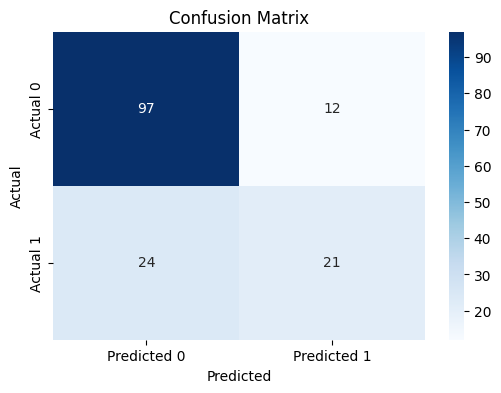

In [12]:
conf_df = pd.DataFrame(
    conf_mat,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)

plt.figure(figsize=(6,4))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
data.columns = [
    'pregnant',
    'glucose',
    'bp',
    'skin',
    'insulin',
    'bmi',
    'pedigree',
    'age',
    'label'
]

In [14]:
feature_cols = ['pregnant', 'glucose', 'bp', 'pedigree', 'insulin', 'bmi']
X = data[feature_cols]
y = data.label